<a href="https://colab.research.google.com/github/PhungHanh/Xulyanh_PhungThiHanh/blob/main/BVU_PhungThiHanh_MIT26K5_Baitapthuchanh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Kết nối đến Google Drive để lấy ảnh
from google.colab import drive
drive.mount('/content/drive')     # Mount (gắn) Google Drive vào không gian lưu trữ của Colab

# Cài đặt các thư viện xử lý ảnh và hiển thị đồ họa cần thiết
import cv2                        #Thư viện OpenCV dùng để xử lý ảnh
import numpy as np                # Thư viện Numpy để tính toán các phép toán trên mảng và ma trận
import matplotlib.pyplot as plt   # Thư viện dùng để hiển thị hình ảnh trực quan
from google.colab.patches import cv2_imshow # Hàm cv2_imshow riêng của Colab để hiển thị ảnh không bị lỗi

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Ảnh gốc:


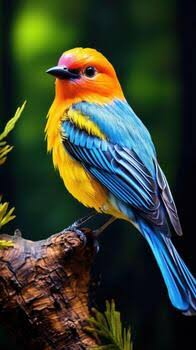

In [ ]:
# 1. Đọc và hiển thị ảnh
image_path = '/content/drive/MyDrive/Xulyanh/Birds.tiff' # Đường dẫn đến file ảnh trên Drive

img = cv2.imread(image_path)  # Đọc ảnh và lưu vào biến 'img'
print("Ảnh gốc:")             # In dòng chữ thông báo
cv2_imshow(img)               # Hiển thị ảnh gốc lên màn hình

Ảnh xám:


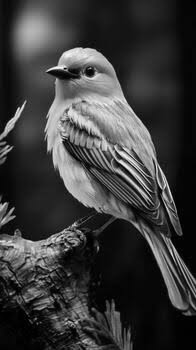

In [ ]:
# 2.Chuyển đổi sang ảnh xám
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Chuyển đổi ảnh màu từ BGR sang ảnh xám (GRAY) bằng hàm cvtColor

print("Ảnh xám:")   # In thông báo
cv2_imshow(gray)    # Hiển thị ảnh xám vừa tạo ra

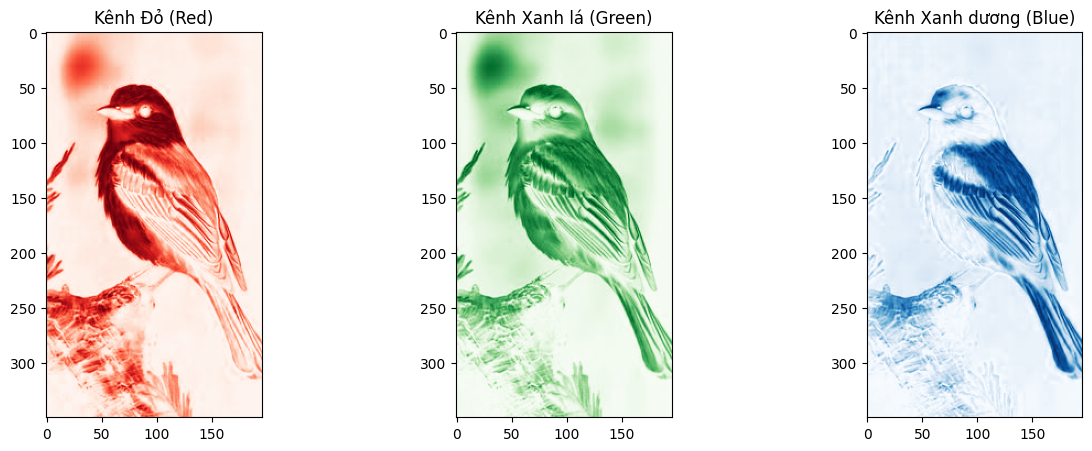

Chiều cao: 350 - Chiều rộng: 196
Độ phân giải: 196 x 350
Giá trị cường độ nhỏ nhất: 0
Giá trị cường độ lớn nhất: 250


In [ ]:
# 3. Tách kênh màu, độ phân giải không gian, cường độ
# a. Tách các kênh màu (Đỏ, Xanh lá, Xanh dương)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    # Chuyển ảnh từ BGR (mặc định) sang RGB để chia kênh
R = img_rgb[:,:,0]      # Trích xuất toàn bộ kênh màu thứ 0 (Đỏ)
G = img_rgb[:,:,1]      # Trích xuất toàn bộ kênh màu thứ 1 (Xanh lá)
B = img_rgb[:,:,2]      # Trích xuất toàn bộ kênh màu thứ 2 (Xanh dương)

# Hiển thị 3 kênh màu bằng matplotlib
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(R, cmap='Reds'); axes[0].set_title("Kênh Đỏ (Red)")
axes[1].imshow(G, cmap='Greens'); axes[1].set_title("Kênh Xanh lá (Green)")
axes[2].imshow(B, cmap='Blues'); axes[2].set_title("Kênh Xanh dương (Blue)")
plt.show()

# b. Độ phân giải không gian
height, width = img.shape[:2] # Lấy chiều cao và chiều rộng của ảnh từ thuộc tính shape
# In ra kích thước ảnh
print("Chiều cao:", height, "- Chiều rộng:", width)
print("Độ phân giải:", width, "x", height)

# c. Cường độ ảnh
# Tìm và in ra giá trị điểm ảnh tối nhất và sáng nhất trong ảnh xám
print("Giá trị cường độ nhỏ nhất:", gray.min())
print("Giá trị cường độ lớn nhất:", gray.max())

Ảnh nhị phân hóa:


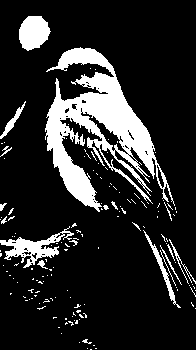

In [ ]:
# 4.Nhị phân hóa từ ảnh
# Biến các điểm ảnh có giá trị > 127 thành 255 (trắng), còn lại thành 0 (đen) bằng hàm cv2.threshold
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

print("Ảnh nhị phân hóa:")
cv2_imshow(binary)

Kết quả phép toán AND:


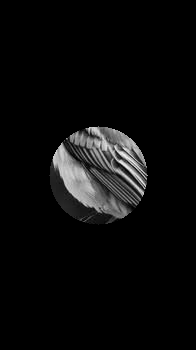

Kết quả phép toán XOR:


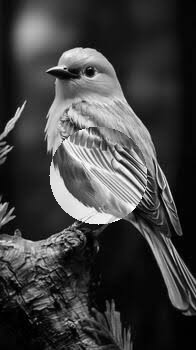

In [ ]:
# 5. Thực hiện phép toán AND, XOR (Tạo một bức ảnh toàn màu đen (chứa toàn số 0) có cùng kích thước với ảnh xám để làm mặt nạ (mask))
mask = np.zeros(gray.shape, dtype="uint8")
cv2.circle(mask, (width // 2, height // 2), min(width, height) // 4, 255, -1) # Vẽ một hình tròn màu trắng (255) nằm ở chính giữa mặt nạ để làm vùng chọn
img_and = cv2.bitwise_and(gray, mask)     # Thực hiện phép toán AND giữa ảnh xám và mặt nạ
img_xor = cv2.bitwise_xor(gray, mask)     # Thực hiện phép toán XOR giữa ảnh xám và mặt nạ

# Hiển thị kết quả phép AND
print("Kết quả phép toán AND:")
cv2_imshow(img_and)

# Hiển thị kết quả phép XOR
print("Kết quả phép toán XOR:")
cv2_imshow(img_xor)

Ảnh sau khi cộng 50 (Sáng hơn):


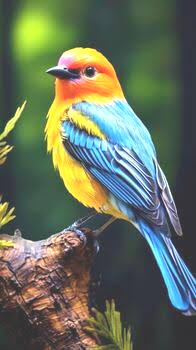

Ảnh sau khi trừ 50 (Tối hơn):


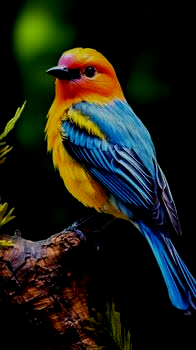

Ảnh phóng to:


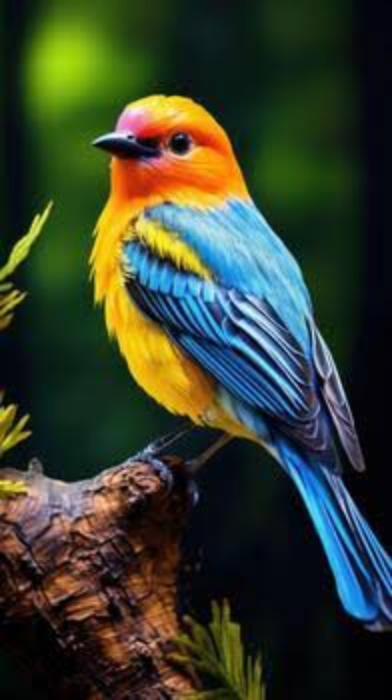

Ảnh thu nhỏ:


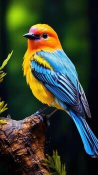

In [ ]:
# 6. Thực hiện phép toán cộng, trừ, phóng to, thu nhỏ ảnh
# a. Cộng cường độ: Tăng độ sáng bằng cách cộng thêm 50 vào mỗi điểm ảnh
add_img = cv2.add(img, 50)
print("Ảnh sau khi cộng 50 (Sáng hơn):")
cv2_imshow(add_img)

# b. Trừ cường độ: Làm tối ảnh bằng cách trừ đi 50 ở mỗi điểm ảnh
sub_img = cv2.subtract(img, 50)
print("Ảnh sau khi trừ 50 (Tối hơn):")
cv2_imshow(sub_img)

# c. Phóng to ảnh: Dùng hàm cv2.resize với tham số tỷ lệ fx=2, fy=2 để gấp đôi kích thước
zoom_in = cv2.resize(img, None, fx=2, fy=2)
print("Ảnh phóng to:")
cv2_imshow(zoom_in)

# d. Thu nhỏ ảnh: Dùng hàm cv2.resize với tỷ lệ fx=0.5, fy=0.5 để giảm đi một nửa kích thước
zoom_out = cv2.resize(img, None, fx=0.5, fy=0.5)
print("Ảnh thu nhỏ:")
cv2_imshow(zoom_out)

Ảnh sau khi chỉnh độ sáng và tương phản:


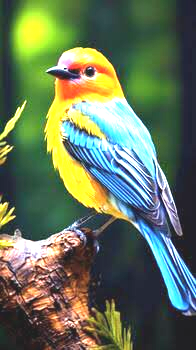

In [ ]:
# 7. Điều chỉnh độ sáng, tương phản
alpha = 1.5       # Thiết lập hệ số alpha để tăng tương phản (1.5 lần)
beta = 30         # Thiết lập hệ số beta để tăng độ sáng (thêm 30 đơn vị)
# Áp dụng công thức biến đổi tuyến tính điểm ảnh: g(x) = alpha * f(x) + beta
# Hàm convertScaleAbs tự động thực hiện phép tính và ép kiểu dữ liệu về dạng 8-bit (0-255)
adjusted_img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

print("Ảnh sau khi chỉnh độ sáng và tương phản:")
cv2_imshow(adjusted_img)

Ảnh lật ngang:


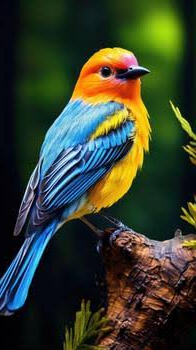

Ảnh lật dọc:


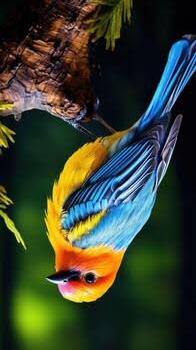

Ảnh xoay 90 độ:


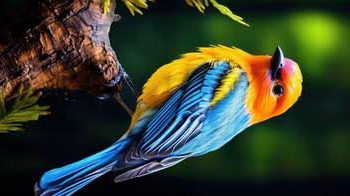

In [ ]:
# 8. Lật và xoay ảnh
# a. Lật ảnh
flip_horizontal = cv2.flip(img, 1)      # Lật ngang (tham số 1)
flip_vertical = cv2.flip(img, 0)        # Lật dọc (tham số 0)
flip_both = cv2.flip(img, -1)           # Lật cả 2 chiều (tham số -1)

# b. Xoay ảnh 90 độ theo chiều kim đồng hồ
rotated_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

print("Ảnh lật ngang:")
cv2_imshow(flip_horizontal)

print("Ảnh lật dọc:")
cv2_imshow(flip_vertical)

print("Ảnh xoay 90 độ:")
cv2_imshow(rotated_img)

Ảnh hệ màu HSV:


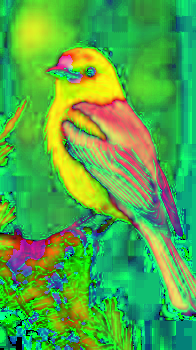

Ảnh hệ màu LAB:


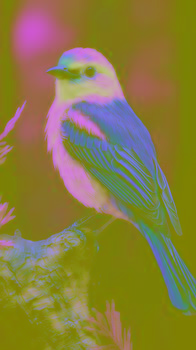

Ảnh hệ màu YCrCb:


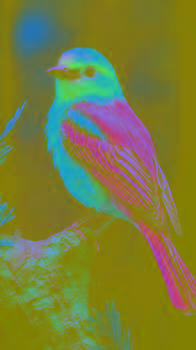

In [ ]:
# 9. Chuyển đổi giữa các hệ màu
# Chuyển đổi từ hệ màu BGR sang HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
print("Ảnh hệ màu HSV:")
cv2_imshow(hsv)

# Chuyển đổi từ hệ màu BGR sang LAB
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
print("Ảnh hệ màu LAB:")
cv2_imshow(lab)

# Chuyển đổi từ hệ màu BGR sang YCrCb
ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
print("Ảnh hệ màu YCrCb:")
cv2_imshow(ycrcb)